In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm

#few utils
from few.utils.utility import get_p_at_t
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux, KerrEccEqFlux #trajectory module. KerrEccEqFlux used to generate p_at_plunge
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens

use_gpu = False #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself.

startup


In [2]:
#fixed parameters
T_LISA = 0.1 #observation time, years. Should be 2.0 for actual runs.
dt = 10.0 #sampling interval, seconds

m1 = 1e6 #MBH mass in solar masses (source frame)
m2 = 10.0 #secondary mass in solar masses (source frame)
x0 = 1.0 #inclination, must be = 1.0 for equatorial model
p0_buffer = 0.5 #while p0 will be determined by T_LISA assuming a plunging EMRI, the StableEMRIFisher code may not be suitable for plunge cases. We thus introduce this small buffer to extend the inspiral.

# initial phases
Phi_phi0 = 0.0 #azimuthal phase
Phi_theta0 = 0.0 #polar phase
Phi_r0 = 0.0 #radial phase

# define the extrinsic parameters
qK = np.pi / 3  # polar spin angle
phiK = np.pi / 4  # azimuthal viewing angle
qS = np.pi / 5  # polar sky angle
phiS = np.pi / 6  # azimuthal viewing angle
dist = 1.0  # distance in Gpc. We'll adjust this later to fix the SNR as SNR_fixed
SNR_fixed = 20.0 #desired SNR throughout the grid.

filename = f'SK_chi2precision_ae_grid' #filename
if not os.path.exists(filename):
    os.mkdir(filename)

filename_Fisher = f'Fishers' #subfolder where all the Fisher matrices will be stored.
filename_Fisher = os.path.join(filename,filename_Fisher)

calculate_Fishers = False #calculate Fisher matrices

SK_traj = EMRIInspiral(func=SuperKludgeFlux)
adiabatic_traj = EMRIInspiral(func=KerrEccEqFlux)

#set SK add_args here. This is where you remove/add pieces.
chi2 = 0.5 #dimensionless secondary spin
evolve_1PA = True #whether to include 1PA corrections.
evolve_primary = False #whether to include primary's evolution
evolve_2PA = True #whether to include 2PA corrections.
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]


In [3]:
#grid parameters over (a and e0)

N = 10 #no. of points along each axis

try:
    with h5py.File(f"{filename}/data.h5", "r") as f:
        param_grid = f["gridpoints"][:]  # Read the dataset into a NumPy array
        p_range = f["p0"][:] + p0_buffer #buffer
    try:
        with h5py.File(f"{filename}/data.h5", "r") as f:
            dist_range = f["dists"][:]  # Read the dataset into a NumPy array
    except KeyError:
        pass #will be handled later
        
except FileNotFoundError:

    #choose parameter ranges here
    a_range = np.linspace(0.1,0.9,N)
    e_range = np.linspace(0.1,0.5,N) #choose wisely: eccentricity above 0.5 is extremely expensive already...
    
    # Generate the Cartesian product of all parameter values
    param_grid = np.array(list((product(a_range, e_range))))
    
    p_range = []
    for i in tqdm(range(len(param_grid))):
        a = param_grid[i,0]
        e0 = param_grid[i,1]

        #generate p0 using the adiabatic trajectory module instead of SK.
        p0 = get_p_at_t(traj_module=adiabatic_traj, t_out=T_LISA, traj_args=[m1, m2, a, e0, x0, Phi_phi0, Phi_theta0, Phi_r0])
        
        p_range.append(p0)

        #check p for plunge trajectories
        #t, p, e, x, pp, pt, pr = kerr_traj(m1, m2, a, p0, e0, x0, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T_LISA, dt=dt)
    
        #print(t[-1] - (T_LISA*YRSID_SI))
        
    p_range = np.array(p_range)

    print(param_grid.shape, p_range.shape)
    
    #save as an h5py file
    with h5py.File(f"{filename}/data.h5", "w") as f:
        f.create_dataset("gridpoints", data=param_grid)
        f.create_dataset("p0", data=p_range) #save plunging traj p0
        
    p_range += p0_buffer #buffer
    
    #with h5py.File(f"{filename}/p_e_grid_data.h5", "r") as f:
    #    loaded_data = f["dataset_name"][:]  # Read the dataset into a NumPy array
    
    #print(loaded_data)
    
    plt.scatter(param_grid[:,0],param_grid[:,1])
    plt.xlabel('a range',fontsize=16)
    plt.ylabel('e0 range',fontsize=16)
    plt.savefig(f"{filename}/grid.png",dpi=300,bbox_inches='tight')
    plt.show()

In [4]:
#initialize waveform model
sum_kwargs = {
    "pad_output": True, # True if you want waveforms always of the length of the LISA observation window (pads by zero if time-series is smaller). Recommended to be True if passing to SEF for near-plunge sources.
}

max_step_days = 10.0 #max trajectory step size in days. Smaller value leads to more stable trajectories, but takes longer to compute. Likely needs fiddling.

inspiral_kwargs = {
    "err":1e-11, #error tolerance in the DOPR integration routine. Default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}

waveform_model = GenerateEMRIWaveform(
            SuperKludgeWaveform, #the waveform class, see few.waveform.waveform.SuperKludgeWaveform
            sum_kwargs=sum_kwargs,
            inspiral_kwargs=inspiral_kwargs,
            return_list=False, #Must be False when interfacing with SEF: If ResponseWrapper provided, it automatically converts to lists. If GenerateEMRIWaveform supplied to SEF, it creates three equally-weighted copies as lists.
            )

#maybe good to add a window for smoothness?

In [5]:
#initialize LISA response model
tdi_gen ="2nd generation"# "1st generation"#

order = 20  # interpolation order (should not change the result too much)
tdi_kwargs_esa = dict(
    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
    order=order, 
    tdi=tdi_gen, 
    tdi_chan="AET",
)

index_lambda = 8 #azimuthal sky location (phiS)
index_beta = 7 #polar sky location (qS)

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

waveform_response = ResponseWrapper(
                        waveform_gen=waveform_model, #the waveform model around which to wrap the Response
                        Tobs=T_LISA,
                        t0=t0,
                        dt=dt,
                        index_lambda=index_lambda,
                        index_beta=index_beta,
                        flip_hx=True,  # set to True if waveform is h+ - ihx (FEW is)
                        use_gpu=use_gpu,
                        is_ecliptic_latitude=False,  # False if using polar angle (theta)
                        remove_garbage="zero",  # removes the beginning of the signal that has bad information
                        **tdi_kwargs_esa,
                        )

In [6]:
#noise model
channels = [A1TDISens, E1TDISens, T1TDISens] #AET TDI channels
noise_kwargs = [{"sens_fn": channel_i} for channel_i in channels] #Keyword argument for each channel to be supplied to get_sensitivity inside SEF

In [7]:
#calulating distances at each grid point such that SNR = some fixed value.

#setup SEF
param_names = ['m1','m2','a','chi2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0'] #parameters to be varied at each grid point.

add_param_args = {'chi2':chi2,
                  '1PA':evolve_1PA,
                  'evolve_primary':evolve_primary,
                  '2PA':evolve_2PA} #dict of parameters NOT included by default in SEF. This contains the additional SK parameters. 

sef_kwargs = {'EMRI_waveform_gen':waveform_response, #EMRI waveform model with TDI response.
              'param_names': param_names, #params to be varied
              'der_order':4, #derivative order. Available options: 2, 4, 6, 8
              'Ndelta':12, #number of stable points, can be any integer.
              'stats_for_nerds': False, #true if you wanna print debugging info
              'stability_plot': False, #true if you wanna plot stability surfaces
              'use_gpu':use_gpu,
              'filename': filename_Fisher, #filename where Fishers to be stored
              'noise_model':get_sensitivity,
              'channels':channels,
              'noise_kwargs':noise_kwargs,
              'add_param_args':add_param_args,
              'plunge_check':False, #save time by avoiding internal check for plunging trajectories (this is ensured by our choice of p0)
             }

emri_kwargs = {'T': T_LISA, 'dt': dt}

try: #dist ranges already available?
    with h5py.File(f"{filename}/data.h5", "r") as f:
        dist_range = f["dists"][:]  # Read the dataset into a NumPy array

except:
    
    dist_range = []
    for i in tqdm(range(len(param_grid))):
        a = param_grid[i][0]
        e0 = param_grid[i][1]
        p0 = p_range[i]
    
        param_list = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
                
        #calculate Fisher
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        SNR_before = sef.SNRcalc_SEF()
        dist_fact = SNR_before/SNR_fixed #adjust distance such that SNR = SNR_fixed
        
        param_list[6] *= dist_fact
        dist_range.append(dist*dist_fact)
    
        del sef #memory management. Not sure if this is actually helpful.
    
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        SNR_after = sef.SNRcalc_SEF()
    
        print("SNR before: ", SNR_before, "SNR_after: ", SNR_after)
    
    #save as an h5py file
    with h5py.File(f"{filename}/data.h5", "a") as f: #"a" flag for appending existing data file.
        f.create_dataset("dists", data=np.array(dist_range))

In [8]:
def logmasstransform(Fisher, m1, m2, index_of_m1 = 0, index_of_m2 = 1):
    """ transform m1, m2 -> lnm1, lnm2. Fisher transformation: https://en.wikipedia.org/wiki/Fisher_information """
    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    J[index_of_m2,index_of_m2] = m2

    return J.T@Fisher@J

In [9]:
#evaluating and saving the Fisher matrices along the grid
for i in tqdm(range(len(param_grid))):

    try:
        #skip Fisher calculation for ones already calculated
        with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
            _ = f["Fisher"][:]
        continue

    except FileNotFoundError:
        a = param_grid[i][0]
        e0 = param_grid[i][1]
        p0 = p_range[i]
        dist = dist_range[i]

        sef_kwargs['suffix'] = i #add a suffix to the Fisher filename

        param_list = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

        #calculate Fisher
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        sef() #execute SEF for Fisher calculation

        #once Fishers calculated (in m1, m2 parametrization), transform to log-masses for numerical stability
        with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
            Fisher = f["Fisher"][:]

        Fisher_transformed = logmasstransform(Fisher, m1, m2)

        with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "a") as f:
            f.create_dataset("Fisher_transformed", data = Fisher_transformed)
    

  0%|                                                   | 0/100 [00:00<?, ?it/s]

wave ndim:  2
waveform shape inside PSD:  (3, 315581)
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.1), 'p0': np.float64(9.730622968277174), 'e0': np.float64(0.1), 'Y0': 1.0, 'dist': np.float64(0.21539830649351338), 'qS': 0.6283185307179586, 'phiS': 0.5235987755982988, 'qK': 1.0471975511965976, 'phiK': 0.7853981633974483, 'Phi_phi0': 0.0, 'Phi_theta0': 0.0, 'Phi_r0': 0.0, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}
Waveform Generated. SNR: 19.999999999999993
The optimal source SNR is <= 20. The Fisher approximation may not be valid!
calculating stable deltas...
waveform shape inside PSD:  (3, 315582)
minimum relative error is greater than 1%. Fisher may be unstable!
Time taken to compute stable deltas is 544.862955570221 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 138.8572850227356 seconds


  1%|▍                                      | 1/100 [12:23<20:27:33, 743.97s/it]

wave ndim:  2
waveform shape inside PSD:  (3, 315581)
Computing SNR for parameters: {'m1': 1000000.0, 'm2': 10.0, 'a': np.float64(0.1), 'p0': np.float64(9.737517821458393), 'e0': np.float64(0.14444444444444446), 'Y0': 1.0, 'dist': np.float64(0.23094775189391675), 'qS': 0.6283185307179586, 'phiS': 0.5235987755982988, 'qK': 1.0471975511965976, 'phiK': 0.7853981633974483, 'Phi_phi0': 0.0, 'Phi_theta0': 0.0, 'Phi_r0': 0.0, 'chi2': 0.5, '1PA': True, 'evolve_primary': False, '2PA': True}
Waveform Generated. SNR: 19.99999999999999
The optimal source SNR is <= 20. The Fisher approximation may not be valid!
calculating stable deltas...
waveform shape inside PSD:  (3, 315582)


  1%|▍                                      | 1/100 [12:32<20:41:39, 752.52s/it]

KeyboardInterrupt



In [11]:
#check Positive Semi-Definiteness of the transformed Fisher Matrices

print("Checking log-mass Fisher positive-definiteness...")

check_flag = True

for i in tqdm(range(len(param_grid))):

    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
        Fisher = f["Fisher"][:]

    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
        Fisher_transformed = f["Fisher_transformed"][:]

    #if you want to exclude sus parameters for troubleshooting
    rows_to_remove = []
    for j in range(len(param_names)):
        if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

    rows_to_remove = np.array(rows_to_remove)
    
    if len(rows_to_remove) > 0:
        Fisher_transformed = np.delete(np.delete(Fisher_transformed,rows_to_remove,axis=0),rows_to_remove,axis=1)
        Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

    if (np.linalg.eigvals(Fisher_transformed) < 0.0).any():
        check_flag = False
        raise ValueError('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")

Checking log-mass Fisher positive-definiteness...


  1%|▍                                         | 1/100 [00:00<00:00, 376.27it/s]


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'SK_chi2precision_ae_grid/Fishers/Fisher_1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

[]

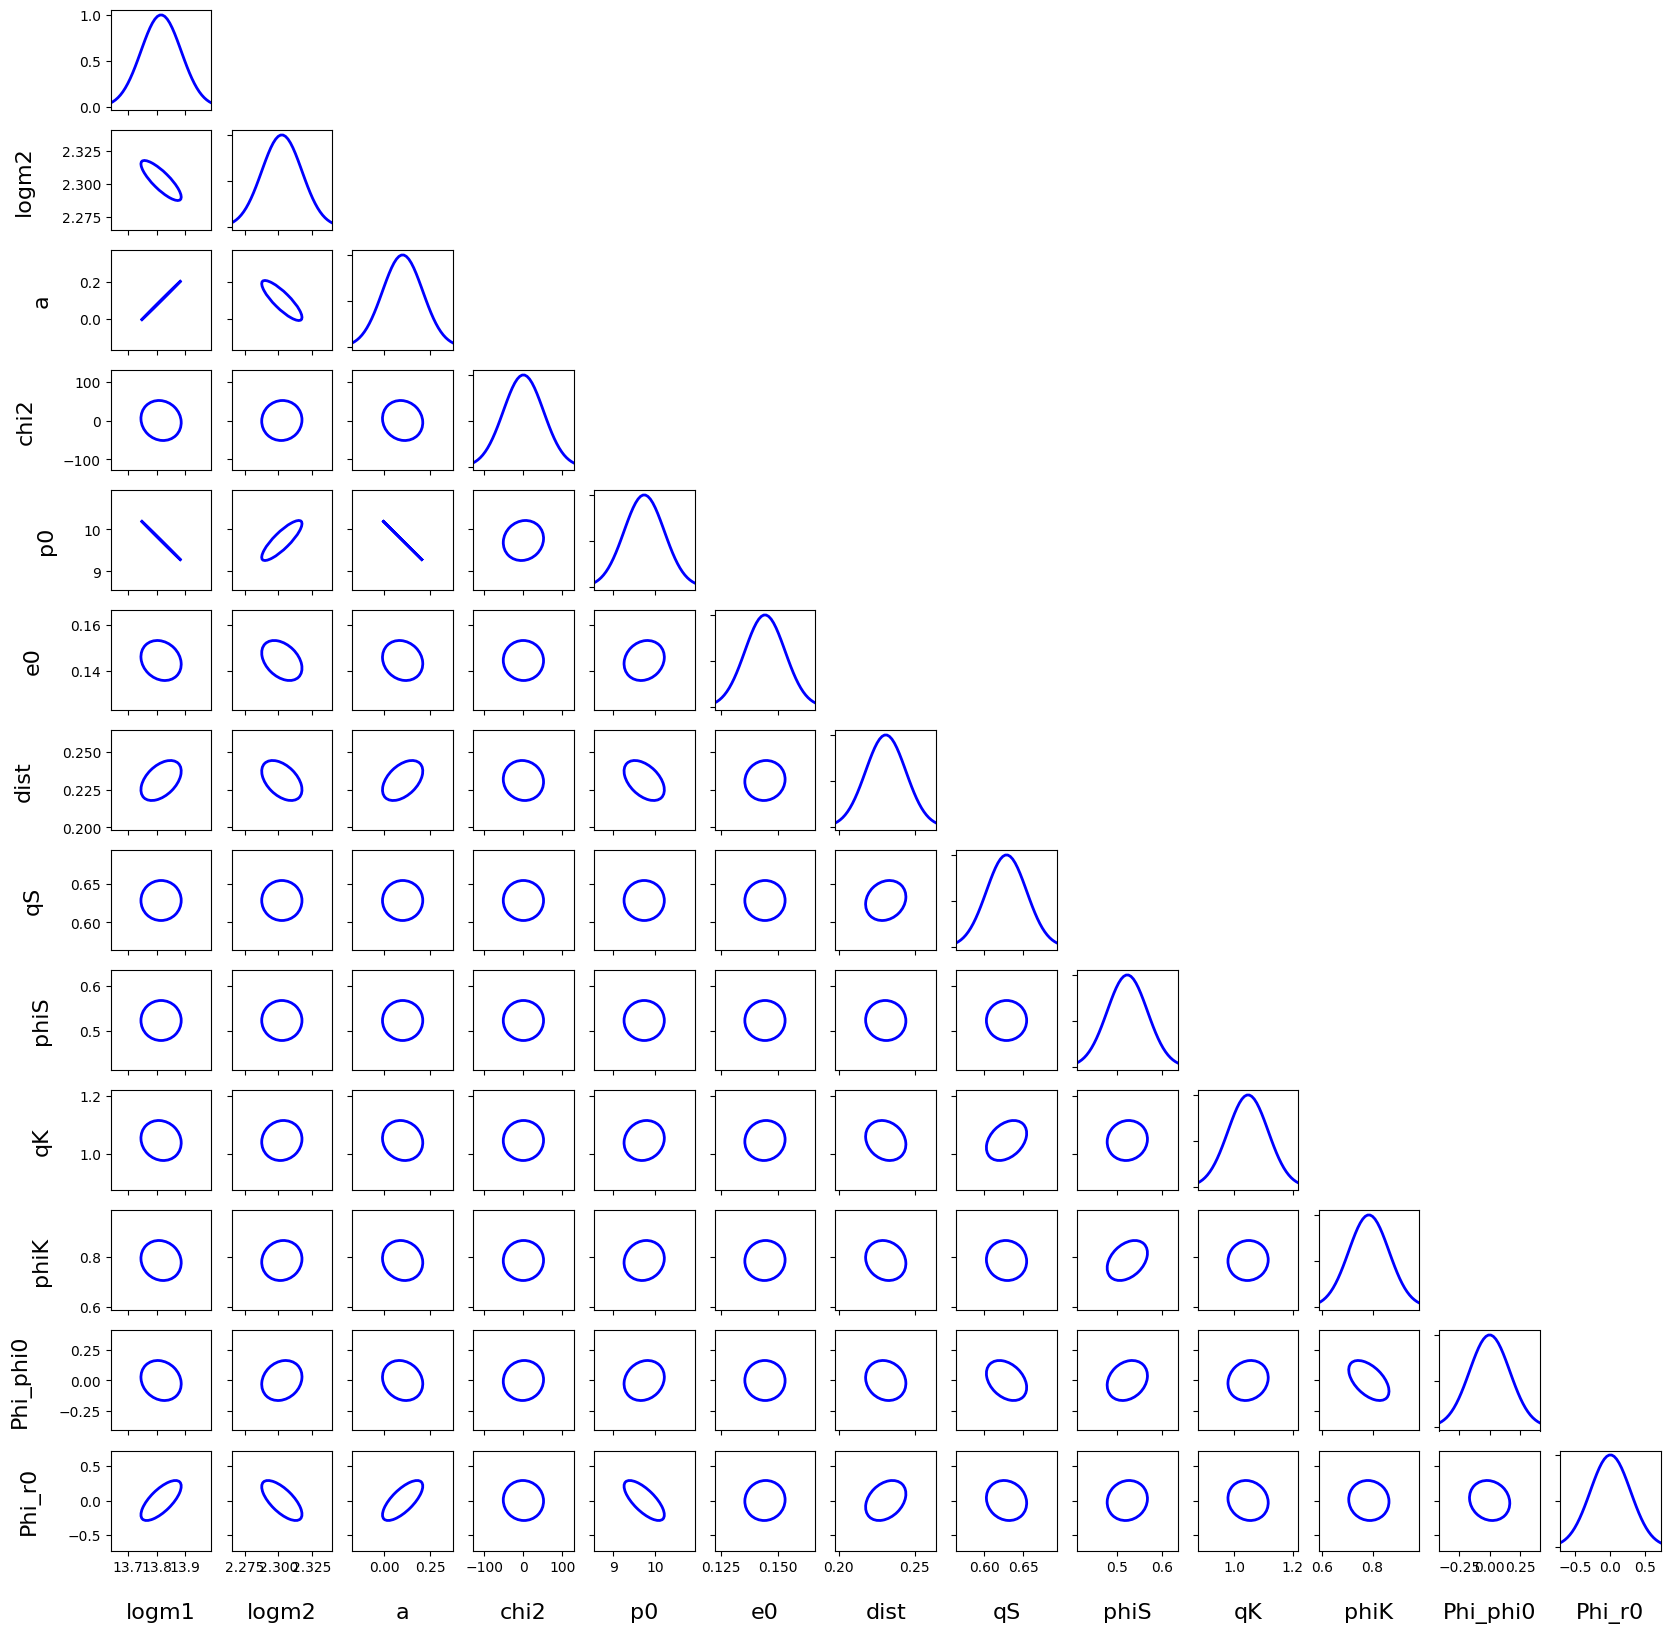

In [19]:
#Quick and dirty visualization. This cell can be removed later.

from stableemrifisher.plot import CovEllipsePlot

param_names = ['logm1','logm2','a','chi2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0'] #parameters to be varied at each grid point.
param_vals = [np.log(m1), np.log(m2), a, chi2, p0, e0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_r0]

wave_params = {}
for i in range(len(param_names)):
    wave_params[param_names[i]] = param_vals[i]

fig, axs = CovEllipsePlot(np.linalg.inv(Fisher_transformed), param_names = param_names, wave_params = wave_params)
plt.plot()